# Análisis Exploratorio de datos
---

**Autor:** Jaime Lozano Cillero

## 1. Descripción del dataset

El conjunto de datos suministrado contiene información sobre reservas de hoteles hechas a lo largo del tiempo, incluyendo detalles sobre los clientes, el comportamiento de reserva y la probabilidad de cancelación.

El objetivo será predecir si una reserva será cancelada (`is_canceled = 1`) o no (`is_canceled = 0`) aplicando modelos de clasificación binaria.


### Descripción de variables

| Nombre Variable                  | Descripción                                              |
| -------------------------------- | -------------------------------------------------------- |
| `hotel`                          | Tipo de hotel: City Hotel o Resort Hotel                 |
| `is_canceled`                    | Variable objetivo: 1 si fue cancelado, 0 si no           |
| `lead_time`                      | Días entre la reserva y la fecha de llegada              |
| `arrival_date_year`              | Año de llegada                                           |
| `arrival_date_month`             | Mes de llegada                                           |
| `arrival_date_week_number`       | Número de la semana del año                              |
| `arrival_date_day_of_month`      | Día del mes de llegada                                   |
| `stays_in_weekend_nights`        | Noches de fin de semana reservadas                       |
| `stays_in_week_nights`           | Noches entre semana reservadas                           |
| `adults`                         | Número de adultos                                        |
| `children`                       | Número de niños                                          |
| `babies`                         | Número de bebés                                          |
| `meal`                           | Tipo de comida reservada                                 |
| `country`                        | País de origen del cliente                               |
| `market_segment`                 | Canal de marketing (online, offline, grupos...)          |
| `distribution_channel`           | Canal de distribución (directo, TA/TO...)                |
| `is_repeated_guest`              | 1 si el cliente ha estado anteriormente                  |
| `previous_cancellations`         | Nº de cancelaciones anteriores                           |
| `previous_bookings_not_canceled` | Nº de reservas previas no canceladas                     |
| `reserved_room_type`             | Tipo de habitación reservada                             |
| `assigned_room_type`             | Tipo de habitación asignada                              |
| `booking_changes`                | Nº de cambios en la reserva                              |
| `deposit_type`                   | Tipo de depósito: No Deposit, Refundable, etc.           |
| `agent`                          | ID del agente (puede ser nulo)                           |
| `company`                        | ID de la empresa (puede ser nulo)                        |
| `days_in_waiting_list`           | Días en lista de espera                                  |
| `customer_type`                  | Tipo de cliente: Transient, Group, etc.                  |
| `adr`                            | Average Daily Rate (precio promedio por noche)           |
| `required_car_parking_spaces`    | Plazas de parking solicitadas                            |
| `total_of_special_requests`      | Nº de peticiones especiales                              |
| `reservation_status`             | Estado final de la reserva: Check-Out, Canceled, No-Show |
| `reservation_status_date`        | Fecha en que se actualizó el estado                      |

## 2. Configuración del Notebook

### Importación de librerías

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

### Definición de constantes

In [ ]:
PATH_DIRECTORIO_DATOS = "../../data"
PATH_DATASET_RAW = f"{PATH_DIRECTORIO_DATOS}/raw/dataset_practica_final.csv"
PATH_DATASET_PROCESSED = f"{PATH_DIRECTORIO_DATOS}/processed/dataset_practica_final_preprocessed.csv"

## 3. Carga de datos y observaciones iniciales

In [3]:
# Cargamos el dataset de la práctica final
df = pd.read_csv(PATH_DATASET_RAW)

# Mostrar la información del dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [5]:
print(f"Dimensiones del dataframe:")
print(f"{df.shape[0]} filas")
print(f"{df.shape[1]} columnas")

Dimensiones del dataframe:
119390 filas
32 columnas


In [6]:
# Fijamos la columna que representa las clases a predecir
target_column = 'is_canceled'

# variable objetivo: is_canceled
df[target_column].value_counts(dropna=False)

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [7]:
# Obtener las frecuencias absolutas de la columna target
df[target_column].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

In [8]:
print(f"\nValores nulos:")
print(f"{df.isna().sum()}")


Valores nulos:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340


Columnas con valores nulos:
- ``children``: imputaremos el valor cero.
- ``country``: imputaremos valor 'unknown'.
- ``agent`` y ``company``: el enunciado del proyecto indica que las ausencias de valor no válidas. Son categóricas, las transformaremos a string e imputaremos '0' a los nulos.

In [9]:
print(f"Filas duplicadas:")
print(f"{df.duplicated().sum()}")


Filas duplicadas:
31994


In [10]:
# Descripción estadística de las columnas numéricas
df.describe(include='number').transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [11]:
# Descripción estadística de las columnas string (object)
df.describe(include='object').transpose()

/var/folders/p6/rzkvpch94kn4zdcqnkvnvhg80000gn/T/ipykernel_20647/840403561.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').transpose()


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


## Preprocesamiento de datos

In [12]:
# Duplicamos el DataFrame para no modificar el original
df_preprocessed = df.copy()

### Descarte de variables

Se considera que se quiere predecir antes de que se consume el hecho de un check-in o que el cliente no se presente. Por eso, se tendrán en cuenta las variables disponibles en el momento de hacer una predicción.

Las variables descartadas son:

- ``reservation_status`` y ``reservation_status_date`` hacen referencia al estado final de la reserva y no se conocerá cuando se quiera hacer una predicción. Además, ``reservation_status`` constituye una **fuga de datos** hacia el conjunto de entrenamiento porque permite predecir la variable objetivo: Canceled y No-Show vienen a ser is_canceled = 1.
- ``assigned_room_type`` se conoce cuando en un momento posterior al de predicción y además constituye **fuga de datos**. Si está asignada un tipo de habitación significa que la reserva no se canceló.
- ``booking_changes`` puede ir variando a lo largo del tiempo, y sólo se conoce su valor real cuando se realiza el check-in o se cancela la reserva.

In [13]:
discarded_columns = ['assigned_room_type', 'booking_changes', 'reservation_status', 'reservation_status_date']
df_preprocessed = df_preprocessed.drop(columns=discarded_columns)

### Limpieza y transformación

In [14]:
# 'agent' y 'company': cambiamos nulos por ceros
for col in ['agent', 'company']:
    df_preprocessed[col] = df_preprocessed[col].fillna(0).astype(int)

# 'children': sustituir el valor nulo por cero.
df_preprocessed['children'] = df_preprocessed['children'].fillna(0).astype(int)

# 'country': sustituir nulos por el valor 'unknown'.
df_preprocessed['country'] = df_preprocessed['country'].fillna('unknown')

# 'arrival_date_month': sustituir valor textual por ordinal.
df_preprocessed['arrival_date_month'] = df_preprocessed['arrival_date_month'].replace({
    'January': '1',
    'February': '2',
    'March': '3',
    'April': '4',
    'May': '5',
    'June': '6',
    'July': '7',
    'August': '8',
    'September': '9',
    'October': '10',
    'November': '11',
    'December': '12'
}).astype(int)


In [15]:
df_preprocessed.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  int64  
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  int64  
 11  babies                          119390 non-null  int64  
 12  meal                       

In [16]:
df_preprocessed.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

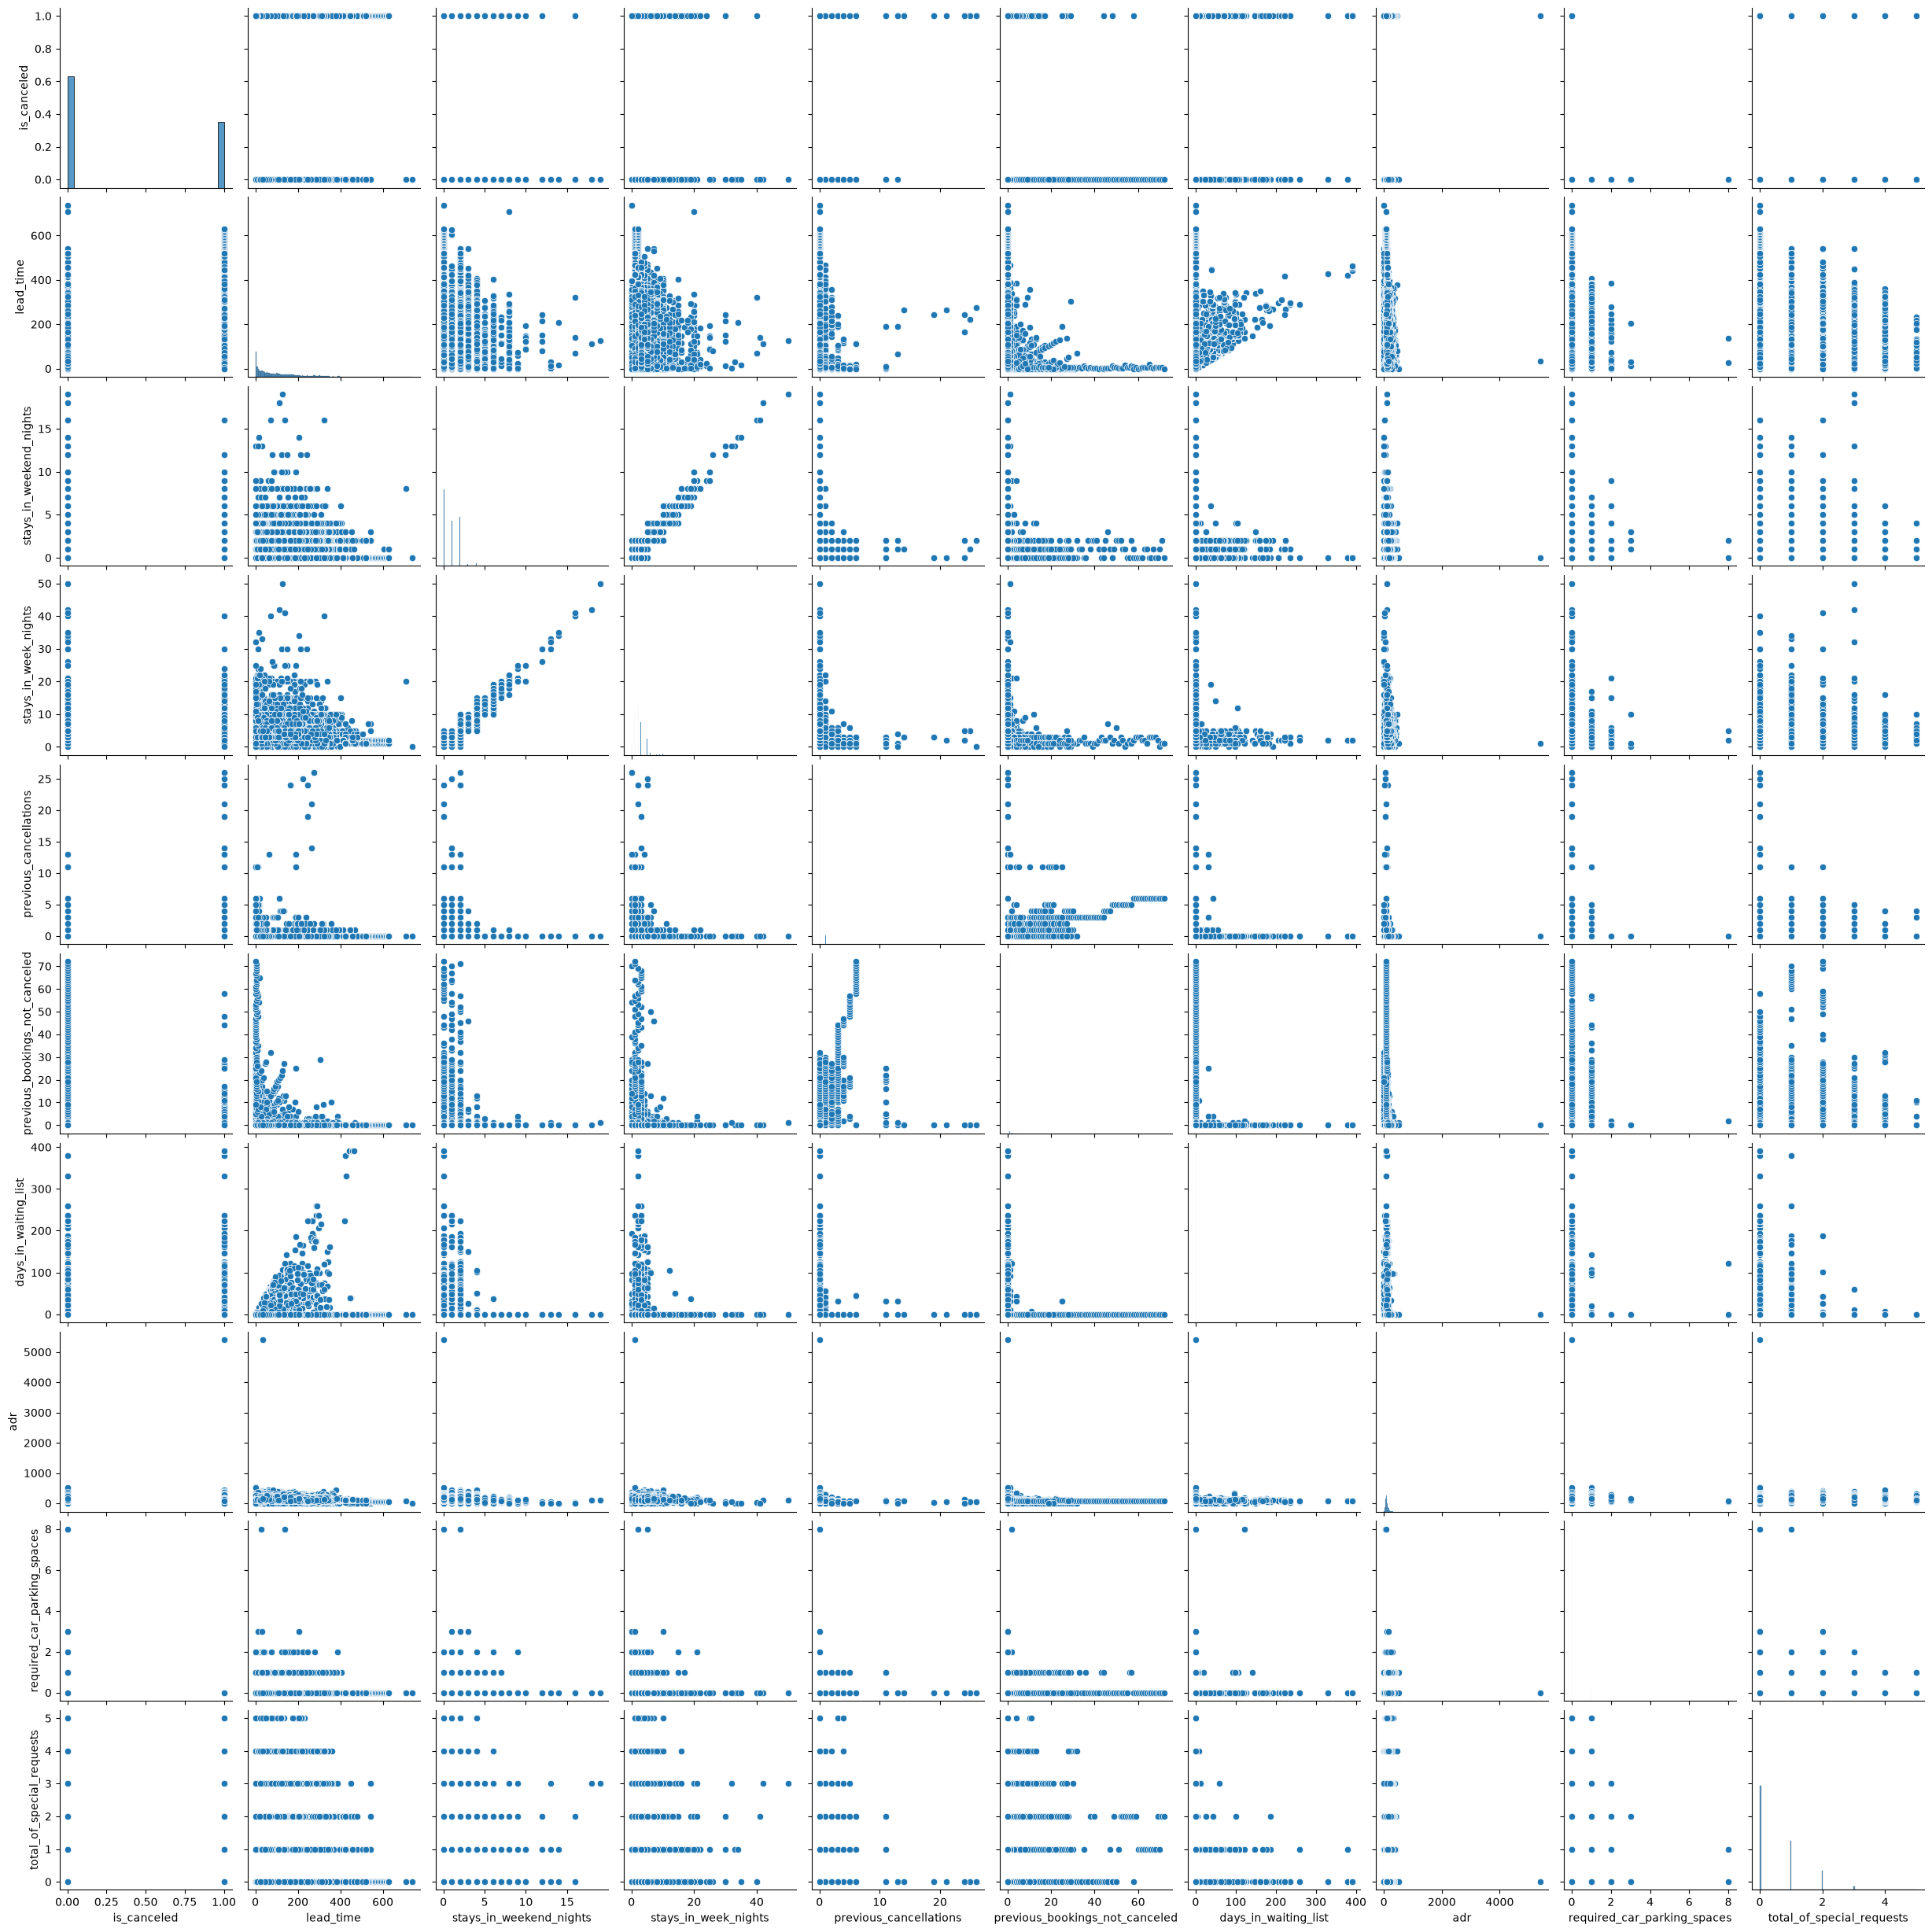

In [17]:
pairplot_column_list = [
    'is_canceled',
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]
sns.pairplot(df_preprocessed[pairplot_column_list])

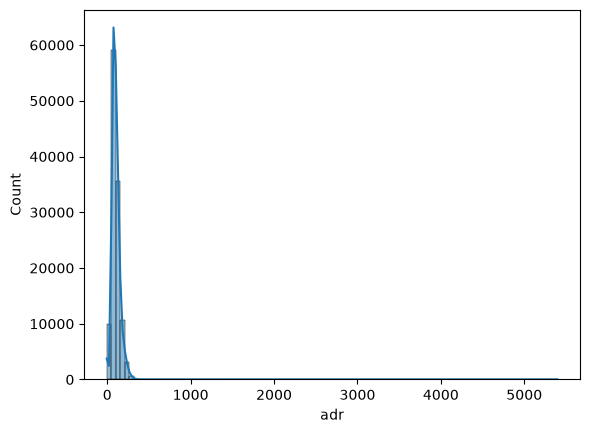

In [18]:
sns.histplot(df['adr'], bins=100, kde=True)
plt.show()

In [19]:
df_preprocessed['adr'].sort_values(ascending=False)

48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
           ...   
110204       0.00
13973        0.00
90028        0.00
0            0.00
14969       -6.38
Name: adr, Length: 119390, dtype: float64

``adr`` tiene un outlier de valor 5400 cuando el siguiente valor más alto es 510. Conviene eliminarlo para que el escalado posterior, entrenamiento y predicción no se vean afectados.

También se observa un solo valor negativo en todo el dataset: -6.38. También lo eliminaremos.

In [20]:
print(df_preprocessed[df_preprocessed['adr'] == 5400])
print(df_preprocessed[df_preprocessed['adr'] == -6.38])

            hotel  is_canceled  lead_time  arrival_date_year  \
48515  City Hotel            1         35               2016   

       arrival_date_month  arrival_date_week_number  \
48515                   3                        13   

       arrival_date_day_of_month  stays_in_weekend_nights  \
48515                         25                        0   

       stays_in_week_nights  adults  ...  previous_bookings_not_canceled  \
48515                     1       2  ...                               0   

       reserved_room_type deposit_type agent company days_in_waiting_list  \
48515                   A   Non Refund    12       0                    0   

       customer_type     adr  required_car_parking_spaces  \
48515      Transient  5400.0                            0   

      total_of_special_requests  
48515                         0  

[1 rows x 28 columns]
              hotel  is_canceled  lead_time  arrival_date_year  \
14969  Resort Hotel            0        195      

In [21]:
print(f"Número filas antes de eliminar: {len(df_preprocessed)}")

df_preprocessed = df_preprocessed[df_preprocessed['adr'] != 5400]
df_preprocessed = df_preprocessed[df_preprocessed['adr'] != -6.38]

print(f"Número filas después de eliminar: {len(df_preprocessed)}")

Número filas antes de eliminar: 119390
Número filas después de eliminar: 119388


In [22]:
# Descripción estadística de las columnas numéricas
df_preprocessed.describe(include='number').transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119388.0,0.370414,0.482918,0.0,0.00,0.000,1.0,1.0
lead_time,119388.0,104.011232,106.863481,0.0,18.00,69.000,160.0,737.0
arrival_date_year,119388.0,2016.156548,0.707478,2015.0,2016.00,2016.000,2017.0,2017.0
arrival_date_month,119388.0,6.552543,3.090610,1.0,4.00,7.000,9.0,12.0
arrival_date_week_number,119388.0,27.165435,13.605100,1.0,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119388.0,15.798254,8.780807,1.0,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119388.0,0.927581,0.998579,0.0,0.00,1.000,2.0,19.0
stays_in_week_nights,119388.0,2.500285,1.908270,0.0,1.00,2.000,3.0,50.0
adults,119388.0,1.856401,0.579266,0.0,2.00,2.000,2.0,55.0
children,119388.0,0.103888,0.398558,0.0,0.00,0.000,0.0,10.0


In [ ]:
os.makedirs("../../data/processed", exist_ok=True)
df_preprocessed.to_csv(PATH_DATASET_PROCESSED, index=False)